In [1]:
from ema_workbench import (
    Model,
    MultiprocessingEvaluator,
    ScalarOutcome,
    IntegerParameter,
    optimize,
    Scenario,
)
from ema_workbench.em_framework.optimization import EpsilonProgress
from ema_workbench.util import ema_logging
from problem_formulation import get_model_for_problem_formulation
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

<class 'ema_workbench.em_framework.model.Model'>


[MainProcess/INFO] pool started with 12 workers
100%|████████████████████████████████████████| 200/200 [00:24<00:00,  8.13it/s]
[MainProcess/INFO] optimization completed, found 94 solutions
[MainProcess/INFO] terminating pool


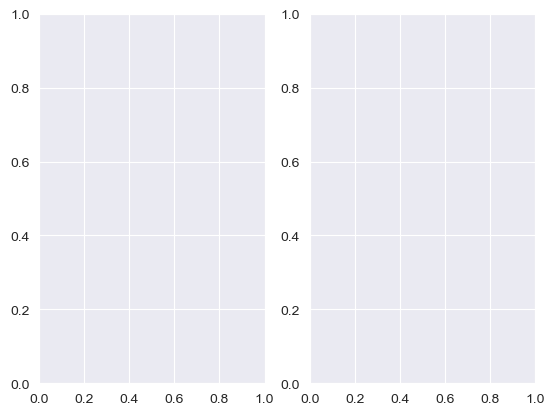

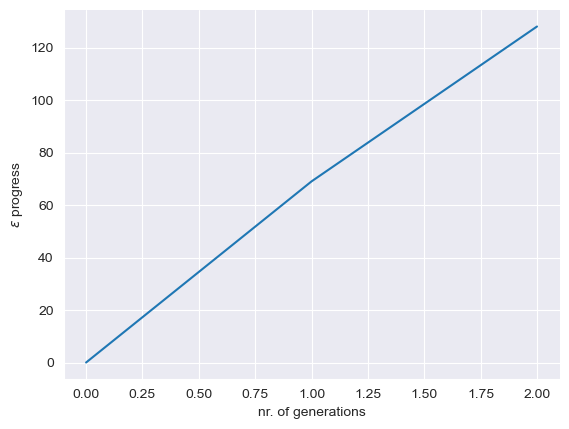

In [2]:
if __name__ == "__main__":
    ema_logging.log_to_stderr(ema_logging.INFO)

    model, steps = get_model_for_problem_formulation(3)
    print(type(model))

    reference_values = {
        "Bmax": 175,
        "Brate": 1.5,
        "pfail": 0.5,
        "discount rate 0": 3.5,
        "discount rate 1": 3.5,
        "discount rate 2": 3.5,
        "ID flood wave shape": 4,
    }
    scen1 = {}

    for key in model.uncertainties:
        name_split = key.name.split("_")

        if len(name_split) == 1:
            scen1.update({key.name: reference_values[key.name]})

        else:
            scen1.update({key.name: reference_values[name_split[1]]})

    ref_scenario = Scenario("reference", **scen1)

    convergence_metrics = [EpsilonProgress()]

    espilon = [1e3] * len(model.outcomes)

    nfe = 200  # proof of principle only, way to low for actual use

    with MultiprocessingEvaluator(model) as evaluator:
        results, convergence = evaluator.optimize(
            nfe=nfe,
            searchover="levers",
            epsilons=espilon,
            convergence=convergence_metrics,
            reference=ref_scenario,
        )

    fig, (ax1, ax2) = plt.subplots(ncols=2, sharex=True)
    fig, ax1 = plt.subplots(ncols=1)
    ax1.plot(convergence.epsilon_progress)
    ax1.set_xlabel("nr. of generations")
    ax1.set_ylabel(r"$\epsilon$ progress")
    sns.despine()


C:\Users\milan\PycharmProjects\EMAworkbench\ema_workbench\analysis\parcoords.py:220: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout(h_pad=0, w_pad=0)


<Figure size 6000x1200 with 0 Axes>

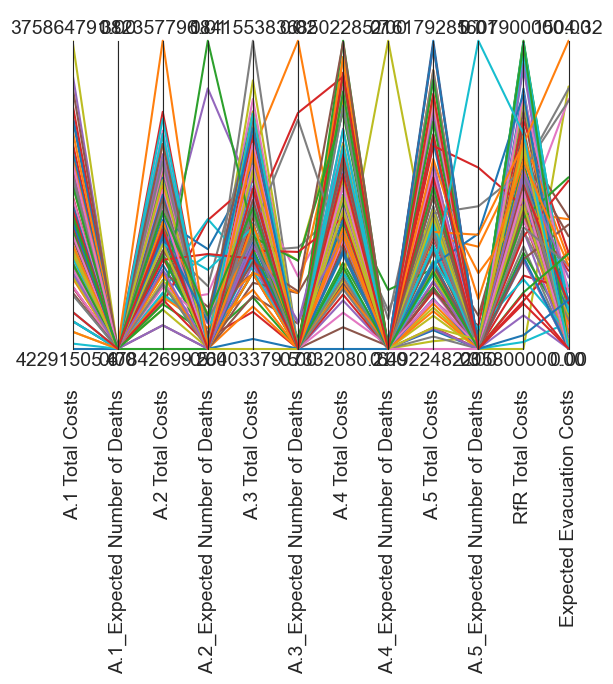

In [3]:
import matplotlib.pyplot as plt
from ema_workbench.analysis import parcoords

data = results.loc[:, [o.name for o in model.outcomes]]
limits = parcoords.get_limits(data)

plt.figure(figsize=(60, 12))  # make the figure wider; adjust numbers as you want

paraxes = parcoords.ParallelAxes(limits)
paraxes.plot(data)

plt.show()

In [4]:
import random
random.seed(20)

In [5]:
import os
from ema_workbench.em_framework.optimization import ArchiveLogger, EpsilonProgress
from ema_workbench import MultiprocessingEvaluator

# Zorg dat de map bestaat
os.makedirs("./archives", exist_ok=True)

# Verwijder bestaand bestand indien nodig
archive_path = "./archives/optimization.tar.gz"
if os.path.exists(archive_path):
    os.remove(archive_path)

# Convergence metrics
convergence_metrics = [
    ArchiveLogger(
        "./archives",
        [l.name for l in model.levers],
        [o.name for o in model.outcomes],
        base_filename="optimization.tar.gz",
    ),
    EpsilonProgress(),
]

# Run de optimalisatie
with MultiprocessingEvaluator(model) as evaluator:
    results, convergence = evaluator.optimize(
        nfe=1000,
        searchover='levers',
        convergence=convergence_metrics,
        epsilons=[0.01] * len(model.outcomes),
        reference=ref_scenario
    )

[MainProcess/INFO] pool started with 12 workers
100%|██████████████████████████████████████| 1000/1000 [01:51<00:00,  9.01it/s]
[MainProcess/INFO] optimization completed, found 316 solutions
[MainProcess/INFO] terminating pool


In [6]:
archives = ArchiveLogger.load_archives("./archives/optimization.tar.gz")

In [8]:
for nfe, archive in archives.items():
    print(f"NFE {nfe}: {len(archive)} rows")

NFE 0: 0 rows
NFE 100: 63 rows
NFE 1000: 316 rows


In [ ]:
import re
import numpy as np
from ema_workbench.em_framework.optimization import to_problem
from ema_workbench import HypervolumeMetric
from platypus import Problem

# ----------------------------------
# 1. Sanitize function for ALL names
# ----------------------------------
def sanitize_name(name):
    name = re.sub(r"[.\s]+", "_", name)  # replaces spaces and dots with underscores
    if re.match(r"^\d", name):
        name = f"x_{name}"               # prefix if name starts with digit
    return name

# ----------------------------------
# 2. Sanitize column names in results
# ----------------------------------
reference_set = results.copy()
reference_set.columns = [sanitize_name(col) for col in reference_set.columns]

# ----------------------------------
# 3. Sanitize column names in archives
# ----------------------------------
for key in archives:
    archives[key].columns = [sanitize_name(col) for col in archives[key].columns]

# ----------------------------------
# 4. Create a new sanitized Problem
# ----------------------------------
orig_problem = to_problem(model, searchover="levers")

sanitized_parameter_names = [sanitize_name(n) for n in orig_problem.parameter_names]
sanitized_outcome_names = [sanitize_name(n) for n in orig_problem.outcome_names]

problem = Problem(len(sanitized_parameter_names), len(sanitized_outcome_names))
problem.types = orig_problem.types
problem.function = orig_problem.function
problem.directions = orig_problem.directions
problem.parameter_names = sanitized_parameter_names
problem.outcome_names = sanitized_outcome_names

# ----------------------------------
# 5. Use it with HypervolumeMetric
# ----------------------------------
hv = HypervolumeMetric(reference_set, problem)
hypervolume = [(nfe, hv.calculate(archive)) for nfe, archive in archives.items()]
hypervolume.sort(key=lambda x: x[0])
hypervolume = np.asarray(hypervolume)

In [10]:
results

,0_RfR 0,0_RfR 1,0_RfR 2,1_RfR 0,1_RfR 1,1_RfR 2,2_RfR 0,2_RfR 1,2_RfR 2,3_RfR 0,...,A.2 Total Costs,A.2_Expected Number of Deaths,A.3 Total Costs,A.3_Expected Number of Deaths,A.4 Total Costs,A.4_Expected Number of Deaths,A.5 Total Costs,A.5_Expected Number of Deaths,RfR Total Costs,Expected Evacuation Costs
0,0,0,0,0,0,0,1,1,1,1,...,2.306841e+08,0.002158,8.560912e+07,0.000000,6.590773e+07,0.000000,1.578034e+08,0.000000,4.694000e+08,168.722926
1,1,1,0,0,1,0,0,1,1,0,...,1.911013e+08,0.003495,1.467362e+08,0.000000,4.277965e+07,0.000000,1.077455e+08,0.001850,7.045000e+08,437.538933
2,1,0,0,0,0,1,1,0,1,0,...,1.831333e+08,0.000000,8.676551e+07,0.000000,2.727903e+07,0.001727,9.455149e+07,0.000000,3.638000e+08,0.000000
3,1,0,1,0,0,1,1,0,0,0,...,1.530433e+08,0.000000,6.231890e+07,0.000000,3.956834e+07,0.000000,1.086282e+08,0.000000,9.162000e+08,0.000000
4,1,0,0,0,1,0,0,1,1,0,...,1.372205e+08,0.000000,1.360111e+08,0.000000,5.243976e+07,0.000000,8.110585e+07,0.000000,6.199000e+08,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,1,1,0,0,0,1,0,0,1,1,...,1.292678e+08,0.004491,7.432910e+07,0.000000,1.637308e+07,0.000000,1.756989e+08,0.000000,1.051100e+09,349.365235
356,1,1,1,1,1,0,0,1,1,0,...,2.563460e+08,0.000000,4.473572e+07,0.003312,2.395362e+07,0.001393,1.359078e+08,0.026234,1.006900e+09,0.000000
357,1,0,0,0,0,0,1,0,0,0,...,1.963903e+08,0.000000,9.672814e+07,0.000000,2.826544e+07,0.000000,1.144608e+08,0.034324,3.714000e+08,0.000000
358,1,0,0,0,0,0,0,0,0,1,...,8.865996e+07,0.012919,7.826286e+07,0.043070,1.427866e+07,0.000106,1.205506e+08,0.000000,8.392000e+08,0.000000


In [18]:
print(dir(problem))

['MAXIMIZE', 'MINIMIZE', '__call__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', 'constraint_names', 'constraints', 'directions', 'ema_constraints', 'evaluate', 'function', 'nconstrs', 'nobjs', 'nvars', 'outcome_names', 'parameter_names', 'parameters', 'reference', 'searchover', 'types']


In [ ]:
results = []
with MultiprocessingEvaluator(model) as evaluator:
    # we run 5 seperate optimizations
    for _ in range(5):
        result = evaluator.optimize(
            nfe=5000, searchover="levers", epsilons=[0.05] * len(model.outcomes), reference=ref_scenario
        )
        results.append(result)

[MainProcess/INFO] pool started with 12 workers
  0%|                                                 | 0/5000 [00:00<?, ?it/s]

In [ ]:
from ema_workbench.em_framework.optimization import epsilon_nondominated, to_problem

problem = to_problem(model, searchover="levers")
epsilons = [0.05] * len(model.outcomes)
merged_archives = epsilon_nondominated(results, epsilons, problem)

In [ ]:
merged_archives.shape

In [ ]:
from ema_workbench.em_framework.optimization import ArchiveLogger, EpsilonProgress

# we need to store our results for each seed
results = []
convergences = []

with MultiprocessingEvaluator(model) as evaluator:
    # we run again for 5 seeds
    for i in range(5):
        # we create 2 covergence tracker metrics
        # the archive logger writes the archive to disk for every x nfe
        # the epsilon progress tracks during runtime
        convergence_metrics = [
            ArchiveLogger(
                "./archives",
                [l.name for l in model.levers],
                [o.name for o in model.outcomes],
                base_filename=f"{i}.tar.gz",
            ),
            EpsilonProgress(),
        ]

        result, convergence = evaluator.optimize(
            nfe=50000,
            searchover="levers",
            epsilons=[0.05] * len(model.outcomes),
            convergence=convergence_metrics,
            reference=ref_scenario
        )

        results.append(result)
        convergences.append(convergence)

In [ ]:
all_archives = []

for i in range(5):
    archives = ArchiveLogger.load_archives(f"./archives/{i}.tar.gz")
    all_archives.append(archives)

In [ ]:
from ema_workbench import (
    HypervolumeMetric,
    GenerationalDistanceMetric,
    EpsilonIndicatorMetric,
    InvertedGenerationalDistanceMetric,
    SpacingMetric,
)
from ema_workbench.em_framework.optimization import to_problem

problem = to_problem(model, searchover="levers")

reference_set = epsilon_nondominated(results, [0.05] * len(model.outcomes), problem)

hv = HypervolumeMetric(reference_set, problem)
gd = GenerationalDistanceMetric(reference_set, problem, d=1)
ei = EpsilonIndicatorMetric(reference_set, problem)
ig = InvertedGenerationalDistanceMetric(reference_set, problem, d=1)
sm = SpacingMetric(problem)


metrics_by_seed = []
for archives in all_archives:
    metrics = []
    for nfe, archive in archives.items():
        scores = {
            "generational_distance": gd.calculate(archive),
            "hypervolume": hv.calculate(archive),
            "epsilon_indicator": ei.calculate(archive),
            "inverted_gd": ig.calculate(archive),
            "spacing": sm.calculate(archive),
            "nfe": int(nfe),
        }
        metrics.append(scores)
    metrics = pd.DataFrame.from_dict(metrics)

    # sort metrics by number of function evaluations
    metrics.sort_values(by="nfe", inplace=True)
    metrics_by_seed.append(metrics)

In [ ]:
sns.set_style("white")
fig, axes = plt.subplots(nrows=6, figsize=(8, 12), sharex=True)

ax1, ax2, ax3, ax4, ax5, ax6 = axes

for metrics, convergence in zip(metrics_by_seed, convergences):
    ax1.plot(metrics.nfe, metrics.hypervolume)
    ax1.set_ylabel("hypervolume")

    ax2.plot(convergence.nfe, convergence.epsilon_progress)
    ax2.set_ylabel("$\epsilon$ progress")

    ax3.plot(metrics.nfe, metrics.generational_distance)
    ax3.set_ylabel("generational distance")

    ax4.plot(metrics.nfe, metrics.epsilon_indicator)
    ax4.set_ylabel("epsilon indicator")

    ax5.plot(metrics.nfe, metrics.inverted_gd)
    ax5.set_ylabel("inverted generational\ndistance")

    ax6.plot(metrics.nfe, metrics.spacing)
    ax6.set_ylabel("spacing")

ax6.set_xlabel("nfe")


sns.despine(fig)

plt.show()

C:\Users\milan\PycharmProjects\EMAworkbench\ema_workbench\analysis\parcoords.py:220: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout(h_pad=0, w_pad=0)


<Figure size 6000x3000 with 0 Axes>

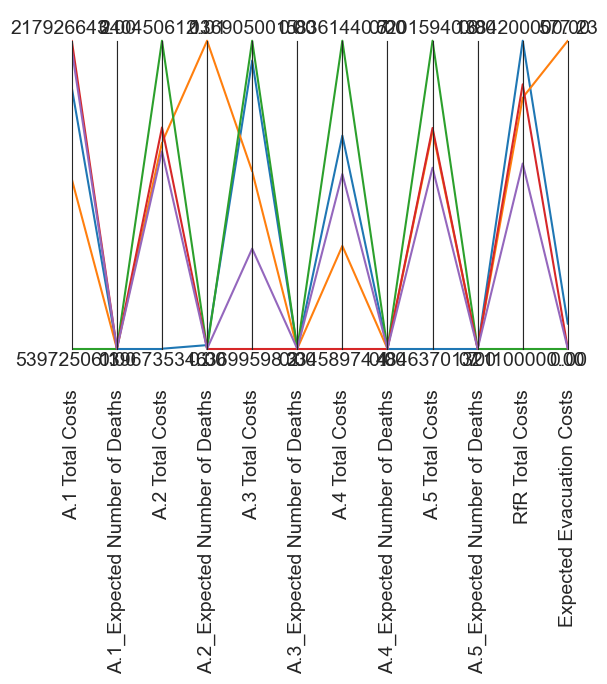

In [25]:
import matplotlib.pyplot as plt
from ema_workbench.analysis import parcoords

data = results.loc[:, [o.name for o in model.outcomes]]

# Define thresholds for "low" values, here using the 10th percentile for each
threshold_deaths = data['A.5_Expected Number of Deaths'].quantile(0.1)
threshold_costs = data['A.5 Total Costs'].quantile(0.1)

# Filter rows where both outcomes are below their thresholds
filtered_data = data[
    (data['A.5_Expected Number of Deaths'] <= threshold_deaths) &
    (data['A.5 Total Costs'] <= threshold_costs)
]

limits = parcoords.get_limits(filtered_data)

plt.figure(figsize=(60, 30))  # wide figure

paraxes = parcoords.ParallelAxes(limits)
paraxes.plot(filtered_data)

plt.show()

In [28]:
# Calculate 10th percentile thresholds for each column
threshold_costs = results['A.5 Total Costs'].quantile(0.1)
threshold_deaths = results['A.5_Expected Number of Deaths'].quantile(0.1)

# Filter rows where both are below the thresholds
filtered_results = results[
    (results['A.5 Total Costs'] <= threshold_costs) &
    (results['A.5_Expected Number of Deaths'] <= threshold_deaths)
]

In [29]:
filtered_results

,0_RfR 0,0_RfR 1,0_RfR 2,1_RfR 0,1_RfR 1,1_RfR 2,2_RfR 0,2_RfR 1,2_RfR 2,3_RfR 0,...,A.2 Total Costs,A.2_Expected Number of Deaths,A.3 Total Costs,A.3_Expected Number of Deaths,A.4 Total Costs,A.4_Expected Number of Deaths,A.5 Total Costs,A.5_Expected Number of Deaths,RfR Total Costs,Expected Evacuation Costs
7,1,1,1,1,1,0,1,0,1,0,...,1.396735e+08,0.000087,1.321846e+08,0.0,5.069078e+07,0.0,4.846370e+07,0.0,1.384200e+09,46.613192
13,1,1,1,1,1,0,0,0,0,1,...,2.070968e+08,0.007404,1.058509e+08,0.0,4.177288e+07,0.0,5.804407e+07,0.0,1.187900e+09,577.226412
26,1,1,0,0,0,0,0,0,1,0,...,2.404506e+08,0.000000,1.369050e+08,0.0,5.836144e+07,0.0,6.201594e+07,0.0,3.211000e+08,0.000000
43,1,0,1,0,1,0,1,1,1,1,...,2.120685e+08,0.000000,6.369960e+07,0.0,3.345897e+07,0.0,5.817663e+07,0.0,1.233700e+09,0.000000
63,0,0,1,0,0,0,0,0,0,1,...,2.042489e+08,0.000000,8.749894e+07,0.0,4.758096e+07,0.0,5.642588e+07,0.0,9.604000e+08,0.000000


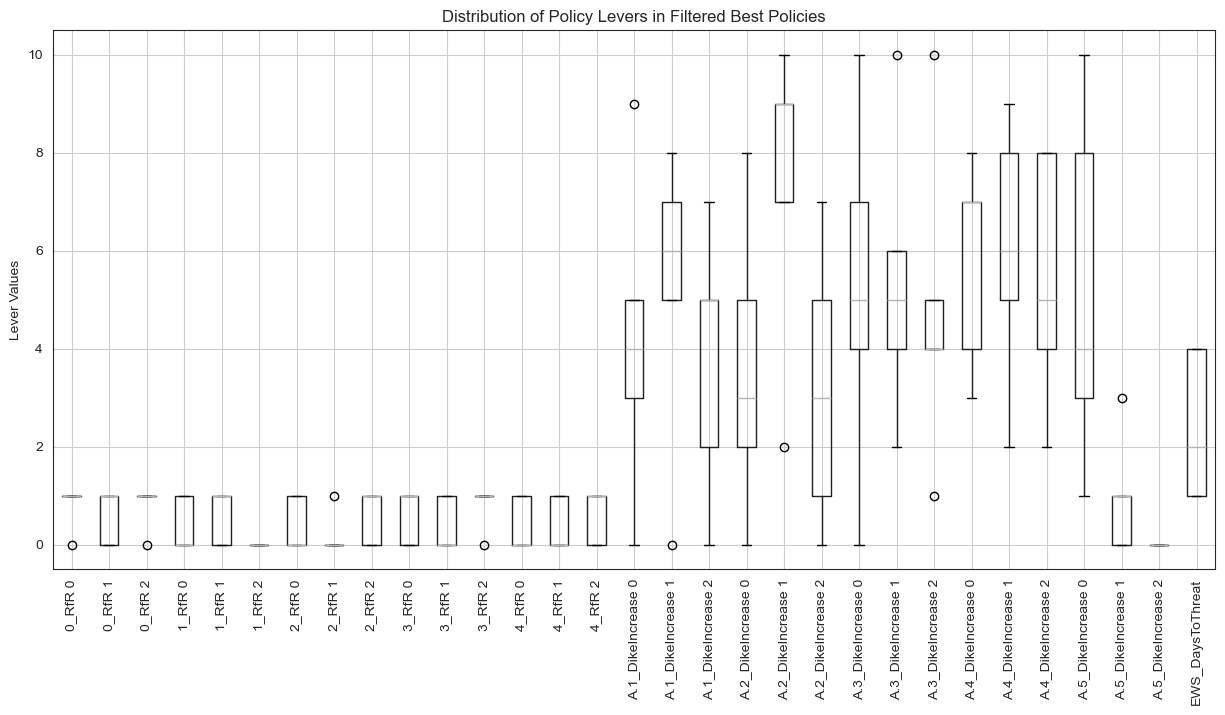

In [30]:
import matplotlib.pyplot as plt

# Assuming filtered_results is your filtered DataFrame from before

# List of policy levers (same as you provided)
policy_levers = [
    '0_RfR 0', '0_RfR 1', '0_RfR 2', '1_RfR 0', '1_RfR 1', '1_RfR 2',
    '2_RfR 0', '2_RfR 1', '2_RfR 2', '3_RfR 0', '3_RfR 1', '3_RfR 2',
    '4_RfR 0', '4_RfR 1', '4_RfR 2',
    'A.1_DikeIncrease 0', 'A.1_DikeIncrease 1', 'A.1_DikeIncrease 2',
    'A.2_DikeIncrease 0', 'A.2_DikeIncrease 1', 'A.2_DikeIncrease 2',
    'A.3_DikeIncrease 0', 'A.3_DikeIncrease 1', 'A.3_DikeIncrease 2',
    'A.4_DikeIncrease 0', 'A.4_DikeIncrease 1', 'A.4_DikeIncrease 2',
    'A.5_DikeIncrease 0', 'A.5_DikeIncrease 1', 'A.5_DikeIncrease 2',
    'EWS_DaysToThreat'
]

# Check if all levers exist in filtered_results columns (optional)
existing_levers = [lever for lever in policy_levers if lever in filtered_results.columns]

# Plot boxplot for those policy levers
plt.figure(figsize=(15, 7))
filtered_results[existing_levers].boxplot(rot=90)
plt.title("Distribution of Policy Levers in Filtered Best Policies")
plt.ylabel("Lever Values")
plt.show()